In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

MARGINALPDBC_CONSOLIDATED_PATH = (
    "/home/einsunza/Desktop/work/code/data/dayahead/consolidated/marginalpdbc.parquet"
)
PCA_START_DATE = "2024-01-01"
PCA_END_DATE = "2025-06-01"

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import wandb

In [3]:
FILE_DIR = os.getcwd()
# parent directory and src directory
SRC_DIR = os.path.join(os.path.dirname(FILE_DIR), "src")
DATA_DIR = os.path.join(os.path.dirname(FILE_DIR), "data")
print(f"Adding src directory to sys.path: {SRC_DIR}")
# Add the src directory to sys.path
sys.path.append(SRC_DIR)

DET_FILEPATH_PATTERN = os.path.join(DATA_DIR, "DET/DET_{YYYYMMDD}.1")
CAB_FILEPATH_PATTERN = os.path.join(DATA_DIR, "CAB/CAB_{YYYYMMDD}.1")
CAPACIDAD_INTER_PBC_FILEPATH_PATTERN = os.path.join(
    DATA_DIR, "capacidad_inter_pbc/capacidad_inter_pbc_{YYYYMMDD}.1"
)

Adding src directory to sys.path: /home/einsunza/Desktop/work/mibel-simulator/src


In [4]:
marginalpdbc_raw = pd.read_parquet(
    MARGINALPDBC_CONSOLIDATED_PATH,
    # filters=[["dat_sesion", "==", pd.to_datetime(STUDIED_DATE)]],
    # engine="pyarrow",
)

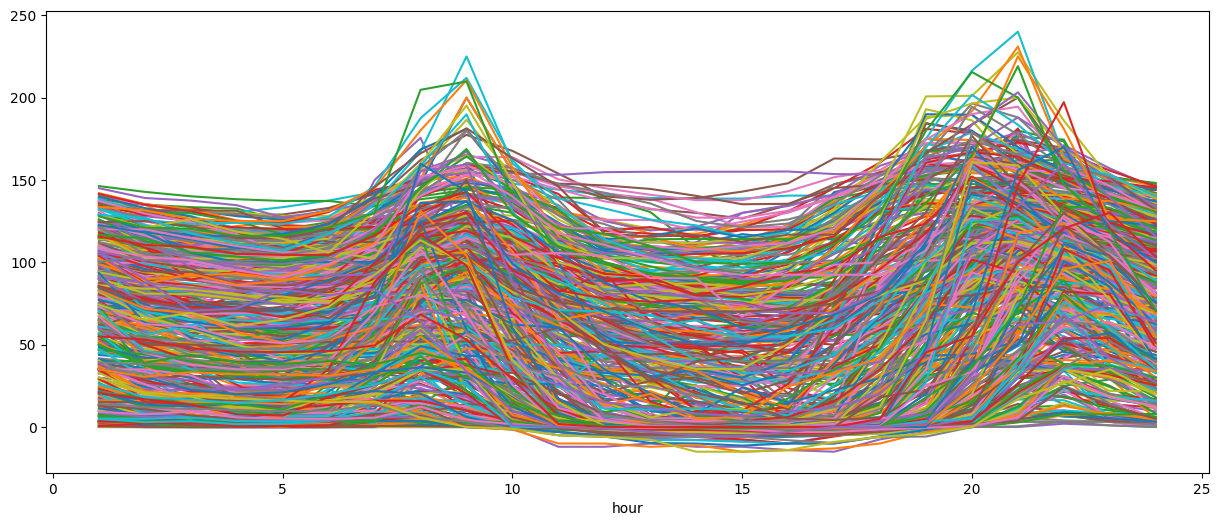

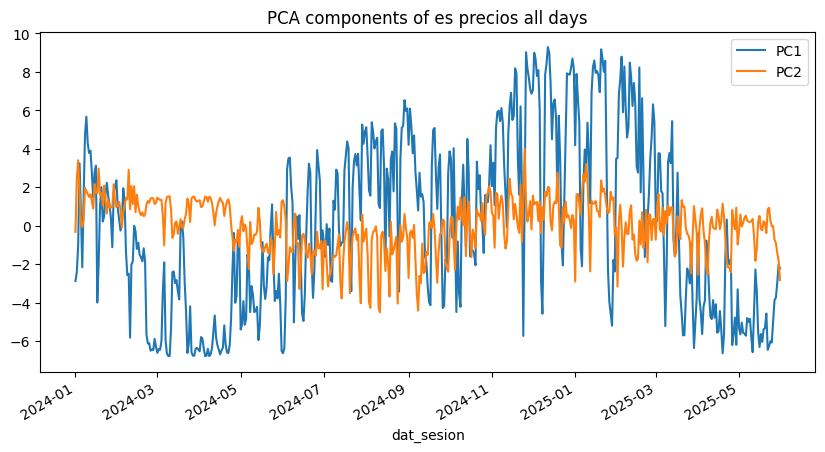

array([0.83500536, 0.08034002])

[0.8350053632248433, 0.9153453860527998]

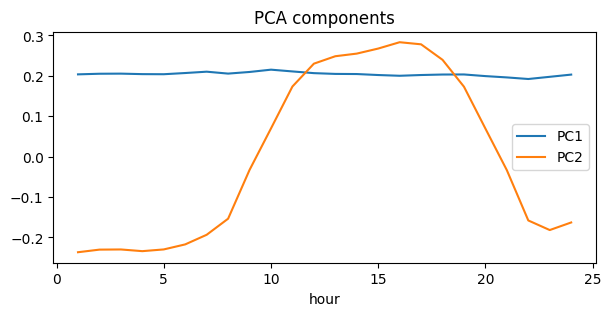

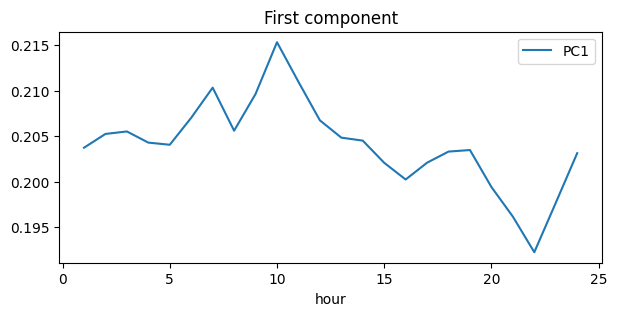

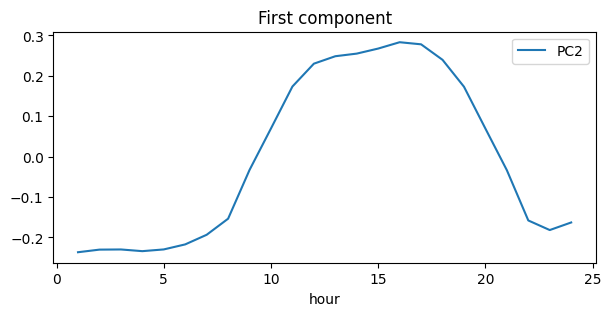

In [5]:
marginalpdbc_es = (
    marginalpdbc_raw.query(
        "@PCA_START_DATE <= dat_sesion < @PCA_END_DATE and hour <= 24"
    )
    .pivot(
        index="dat_sesion",
        columns="hour",
        values="precio_es",
    )
    .dropna()
)
marginalpdbc_es.T.plot(figsize=(15, 6), legend=False)
plt.show()

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler

preprocessor = StandardScaler()
X = preprocessor.fit_transform(marginalpdbc_es)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_pca_es = pca.fit_transform(X)
X_pca_es_df = pd.DataFrame(
    X_pca_es,
    index=marginalpdbc_es.index,
    columns=[f"PC{i+1}" for i in range(X_pca_es.shape[1])],
)
X_pca_es_df.plot(
    figsize=(10, 5), legend=True, title="PCA components of es precios all days"
)
plt.show()
display(pca.explained_variance_ratio_)  # first 3 components explain 90% of variance
display(pca.explained_variance_ratio_.cumsum().tolist())

pca_components_es_df = pd.DataFrame(
    pca.components_.T,
    index=marginalpdbc_es.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
)

pca_components_es_df.plot(figsize=(7, 3), legend=True, title="PCA components")
plt.show()

first_component = pca_components_es_df.iloc[:, 0]
first_component.plot(figsize=(7, 3), legend=True, title="First component")
plt.show()

second_component = pca_components_es_df.iloc[:, 1]
second_component.plot(figsize=(7, 3), legend=True, title="First component")
plt.show()

In [6]:
def get_price_curves(studied_date):
    spain_cleared_prices_date = marginalpdbc_raw.query(
        f'dat_sesion == "{studied_date}"'
    ).set_index("hour", verify_integrity=True)["precio_es"]

    spain_cleared_prices_date_np = spain_cleared_prices_date.to_numpy()
    # spain_cleared_prices_date.plot(
    #     title=f"Spain Cleared Prices on {studied_date}",
    #     ylabel="€/MWh",
    #     xlabel="Hour of the day",
    # )
    spain_cleared_prices_date_scaled = preprocessor.transform(
        spain_cleared_prices_date_np.reshape(1, -1)
    )
    spain_cleared_prices_date_scaled = spain_cleared_prices_date_scaled.flatten()

    multipliers = np.arange(-20, 20, 0.5)

    price_curves_scaled = [
        spain_cleared_prices_date_scaled + m * first_component for m in multipliers
    ]
    price_curves = preprocessor.inverse_transform(price_curves_scaled)
    return price_curves

/tmp/ipykernel_1053880/1711850340.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  spain_cleared_prices_date = marginalpdbc_raw.query(


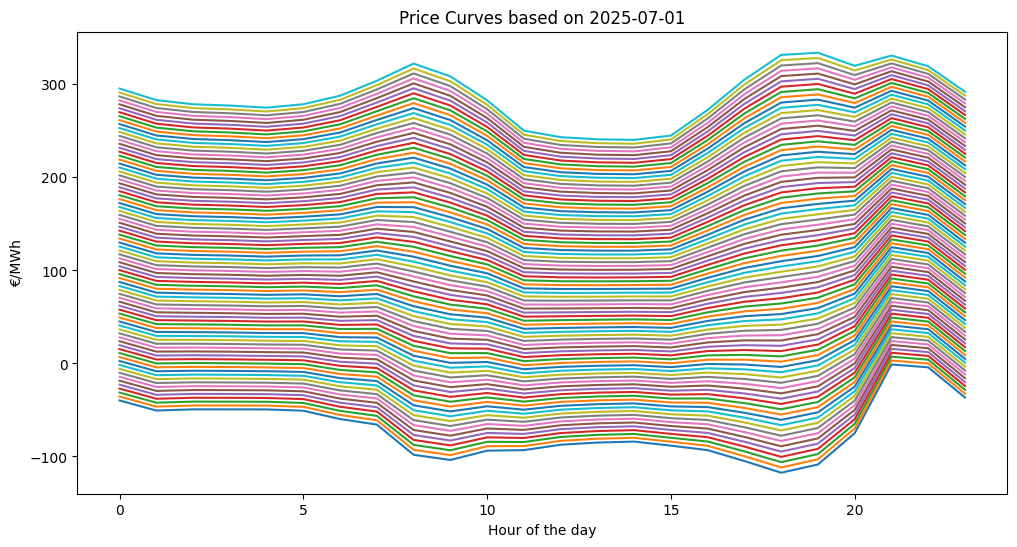

In [7]:
DATE = "2025-07-01"

price_array = get_price_curves(DATE)
fig, ax = plt.subplots(figsize=(12, 6))
plt.plot(price_array.T)
plt.title(f"Price Curves based on {DATE}")
plt.xlabel("Hour of the day")
plt.ylabel("€/MWh")
plt.show()

In [9]:
from mibel_simulator.calculate_residual_demand_with_price_curves import (
    calculate_residual_demand_with_price_curves,
)
from mibel_simulator.const import RDC_ENERGY_COLUMNS, RDC_PRICE_COLUMNS

returned_dict = {
    "only_simple_submitted_relaxed_residual_demand": "only_simple_rdc",
    "submitted_relaxed_residual_demand_curves": "submitted_relaxed_rdc",
    "complex_residual_demand_I_without_market_split_curves": "complex_I_rdc",
    "complex_residual_demand_II_with_market_split_curves": "complex_II_rdc",
}

START_DATE = "2025-06-15"  # "2025-06-15"
END_DATE = "2025-07-15"

for date in pd.date_range(start=START_DATE, end=END_DATE):
    try:
        det_date = DET_FILEPATH_PATTERN.replace("{YYYYMMDD}", date.strftime("%Y%m%d"))
        cab_date = CAB_FILEPATH_PATTERN.replace("{YYYYMMDD}", date.strftime("%Y%m%d"))
        capacidad_inter_date = CAPACIDAD_INTER_PBC_FILEPATH_PATTERN.replace(
            "{YYYYMMDD}", date.strftime("%Y%m%d")
        )

        residual_demand_with_price_curves = calculate_residual_demand_with_price_curves(
            price_array, det_date, cab_date, capacidad_inter_date
        )

        rdc_analytic_dfs = [
            residual_demand_with_price_curves[
                "only_simple_submitted_relaxed_residual_demand"
            ][RDC_PRICE_COLUMNS]
        ]

        for key, short_key in returned_dict.items():
            df = residual_demand_with_price_curves[key][RDC_ENERGY_COLUMNS].copy()
            df.columns = [short_key + "_" + str(col) for col in df.columns]
            rdc_analytic_dfs.append(df)
        rdc_analytics_df = pd.concat(rdc_analytic_dfs, axis=1)
        rdc_analytics_df.to_parquet(
            f"results/rdc_analytics_{date.strftime('%Y%m%d')}.parquet"
        )
    except Exception as e:
        print(f"Error processing date {date}: {e}")
        continue

Period 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: /home/einsunza/Desktop/work/mibel-simulator/data/DET/DET_20250615.1


23 2755.75


Period 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: /home/einsunza/Desktop/work/mibel-simulator/data/DET/DET_20250616.1


18 2785.5


Period 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: /home/einsunza/Desktop/work/mibel-simulator/data/DET/DET_20250617.1


20 2803.3333333333335


Period 25 size is less than 0.1 times the size of the other periods, dropping it. You can ignore this, this is a typical issue with OMIE det files. File: /home/einsunza/Desktop/work/mibel-simulator/data/DET/DET_20250618.1


21 2775.7083333333335
